# Research Questions
1. Which movie genres and content types yield the most box office revenue and profits?
# This helps to determine which kind of movies to prioritize in terms of profitability and revenue.
2. What is the relationship between box office success and production budget, and what production budget rangs generates the highest return on investment?
# Analysing the budget helps to compare the investment and return hence deciding on how much money to invest in a particular film.
3. How do external factors such as movie ratings, runtime and release timing affect box office performance?
# Analysing external factors influence on box office performance helps to optimize when and how to release films.

In [26]:
#Importing libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

In [27]:
#Loading data
bom=pd.read_csv('zippedData/bom.movie_gross.csv.gz')
bom

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [28]:
zip_path = "zippedData/im.db.zip"   # <-- your zip file
extract_path = "zippedData/" 

In [29]:
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print("Unzipped successfully!")
else:
    print("Zip file not found!")

Unzipped successfully!


In [30]:
conn = sqlite3.connect("zippedData/im.db")
cur = conn.cursor()

tables=pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

tables


,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [31]:
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
movie_basics=pd.read_sql('SELECT * FROM movie_basics',conn)
movie_basics.head()


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [32]:
#Using sqlite3 with pandas
#df=pd.read_sql(query,conn)
movie_ratings=pd.read_sql('SELECT * FROM movie_ratings',conn)
movie_ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [33]:
tn=pd.read_csv('zippedData/tn.movie_budgets.csv.gz')
tn

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"
...,...,...,...,...,...,...
5777,78,"Dec 31, 2018",Red 11,"$7,000",$0,$0
5778,79,"Apr 2, 1999",Following,"$6,000","$48,482","$240,495"
5779,80,"Jul 13, 2005",Return to the Land of Wonders,"$5,000","$1,338","$1,338"
5780,81,"Sep 29, 2015",A Plague So Pleasant,"$1,400",$0,$0


#4.1 DATA CLEANING

In [34]:
#Data inspecting 
def inspect(df, name):
    print(f"\n--- {name} ---")
    print(df.head())
    print(df.info())
    print(df.describe(include='all'))

inspect(bom, 'BOM Movie Gross')
inspect(tn, 'TN Movie Budgets')
inspect(tables, 'IMDB Movies')


--- BOM Movie Gross ---
                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year       

In [35]:
#Find Missing Values
print("BOM Movie Gross missing values:")
print(bom.isnull().sum())

print("\nTN Movie Budgets missing values:")
print(tn.isnull().sum())

print("\nIMDB Movies (tables) missing values:")
print(tables.isnull().sum())

BOM Movie Gross missing values:
title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

TN Movie Budgets missing values:
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64

IMDB Movies (tables) missing values:
name    0
dtype: int64


In [36]:
# Establishing the data types of foreign gross
bom['foreign_gross'].dtype

dtype('O')

In [37]:
# # Establishing the data types of domestic gross
bom['domestic_gross'].dtype

dtype('float64')

In [38]:
#Establishing the data types of domestic gross
bom['studio'].dtype

dtype('O')

In [39]:
#Converting foreign_gross
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')


In [40]:
#Converting Date into Datetime
#For bom.movie_gross data, we are using the year column
# Convert Year to integer
bom['year'] = bom['year'].astype(int)

#For tn.movie_budgets, we format the release_date column
tn['release_date'] = pd.to_datetime(tn['release_date'])

#Extract Month and Year
tn['release_month'] = tn['release_date'].dt.month
tn['release_year'] = tn['release_date'].dt.year

In [41]:
# Clean TN Movie Budgets 
# Remove $ and commas
cols = ['production_budget', 'domestic_gross', 'worldwide_gross']

for col in cols:
    tn[col] = tn[col].replace({'\$': '', ',': ''}, regex=True)
    tn[col] = pd.to_numeric(tn[col], errors='coerce')

In [42]:
# Clean Movie_basics  Data
movie_basics.columns

Index(['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres'],
      dtype='object')

In [43]:

# Keep only relevant columns

movie_basics = movie_basics[['movie_id', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres']]

# Rename for merging
movie_basics.rename(columns={'primary_title': 'title'}, inplace=True)

In [44]:
#checking columns in movie_ratings data
movie_ratings.columns

Index(['movie_id', 'averagerating', 'numvotes'], dtype='object')

In [45]:
# Cleaning Movie_ratings data
# Merge ratings with movie_basics
ratings_basics = pd.merge(movie_basics, movie_ratings, on='movie_id', how='inner')

In [46]:
# Lowercase titles for consistency
bom['title'] = bom['title'].str.lower()
tn['movie'] = tn['movie'].str.lower()
ratings_basics['title'] = ratings_basics['title'].str.lower()

In [47]:
# Replacing Missing Values
# Replacing studio values
bom['studio']=bom['studio'].fillna('unknown')
#Replacing domestic_grosss missing values
domestic_median=bom['domestic_gross'].median()
bom['domestic_gross'] = bom['domestic_gross'].fillna(domestic_median)

#Replacing foreign_grosss missing values
foreign_mean = bom['foreign_gross'].mean()
bom['foreign_gross'] = bom['foreign_gross'].fillna(foreign_mean)

In [48]:
# Merging Datasets
# Merge revenue + budget
merged = pd.merge(
    bom,
    tn,
    left_on='title',
    right_on='movie',
    how='inner'
)

In [49]:
# Merge with ratings
merged_1 = pd.merge(
    merged,
    ratings_basics,
    on='title',
    how='inner'
)

# DATA ANALYSIS

# Total revenue Generated by genre

In [65]:
# Create total gross:
bom['total_revenue'] = bom['domestic_gross'] + bom['foreign_gross']

In [ ]:
# Top-performing movies
# Focus on high-revenue genres

bom[['title', 'domestic_gross', 'foreign_gross', 'total_revenue']] \
.sort_values(by='total_revenue', ascending=False) \
.head(10)

,title,domestic_gross,foreign_gross,total_revenue
727,marvel's the avengers,623400000.0,895500000.0,1.518900e+09
1875,avengers: age of ultron,459000000.0,946400000.0,1.405400e+09
3080,black panther,700100000.0,646900000.0,1.347000e+09
328,harry potter and the deathly hallows part 2,381000000.0,960500000.0,1.341500e+09
2758,star wars: the last jedi,620200000.0,712400000.0,1.332600e+09
3081,jurassic world: fallen kingdom,417700000.0,891800000.0,1.309500e+09
1127,frozen,400700000.0,875700000.0,1.276400e+09
2759,beauty and the beast (2017),504000000.0,759500000.0,1.263500e+09
3082,incredibles 2,608600000.0,634200000.0,1.242800e+09
1128,iron man 3,409000000.0,805800000.0,1.214800e+09


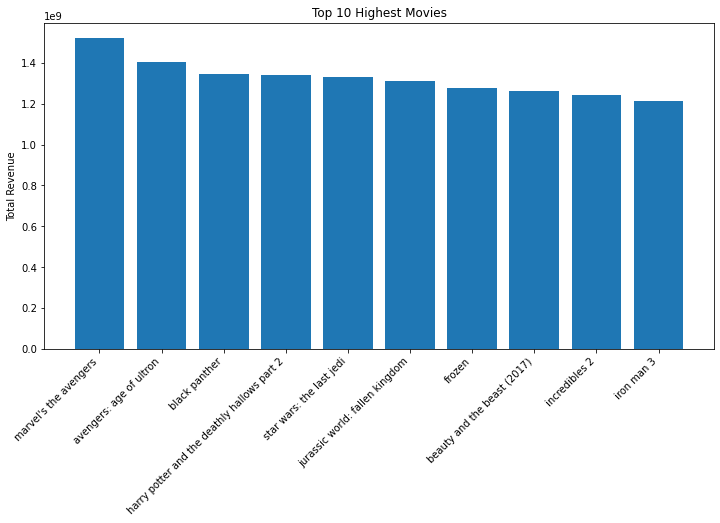

In [70]:
# Visualizing the top 10 videos based on total revenue
top10 = bom.sort_values(by='total_revenue', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10['title'], top10['total_revenue'])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Highest Movies")
plt.ylabel("Total Revenue")
plt.show()

In [73]:
# Studio performance
studio_perf= bom.groupby('studio')['total_revenue'].mean().sort_values(ascending=False).head(10)
studio_perf

studio
HC          8.703000e+08
P/DW        5.076500e+08
BV          4.199350e+08
GrtIndia    2.542000e+08
WB (NL)     2.313279e+08
Fox         2.290844e+08
WB          2.256180e+08
Sony        2.064242e+08
Uni.        2.054932e+08
Par.        1.987590e+08
Name: total_revenue, dtype: float64

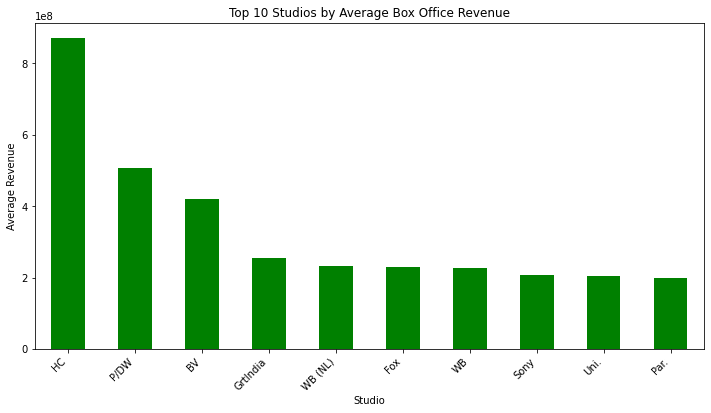

In [74]:
# Visualizing Studio performance based on average total revenue
plt.figure(figsize=(12,6))
studio_perf.plot(kind='bar', color='green')

plt.title("Top 10 Studios by Average Box Office Revenue")
plt.ylabel("Average Revenue")
plt.xlabel("Studio")
plt.xticks(rotation=45, ha='right')

plt.show()

In [85]:
# Total revenue Yearly trends
yearly_total_revenue=bom.groupby('year')['total_revenue'].sum().sort_index()

# Is revenue growing over time
yearly_total_revenue

year
2010    2.558898e+10
2011    3.369399e+10
2012    3.918285e+10
2013    3.829500e+10
2014    3.909926e+10
2015    4.592170e+10
2016    4.846564e+10
2017    4.179381e+10
2018    3.877346e+10
Name: total_revenue, dtype: float64

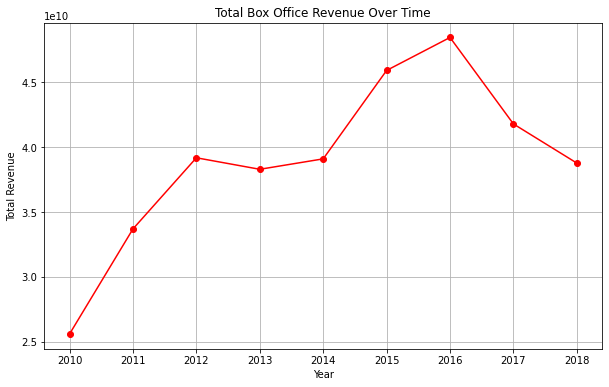

In [80]:
# Visualizing total yearly revenue

plt.figure(figsize=(10,6))

plt.plot(yearly_total_revenue.index, yearly_total_revenue.values, marker='o', color='red')

plt.title("Total Box Office Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.grid(True)

plt.show()

In [83]:
# Compariion of Domestic vs Foreign market in terms of total revenue
# Global appeal is critical
# Think globally, not locally
market_avg= bom[['domestic_gross', 'foreign_gross']].mean()
market_avg

domestic_gross    2.851978e+07
foreign_gross     7.505704e+07
dtype: float64

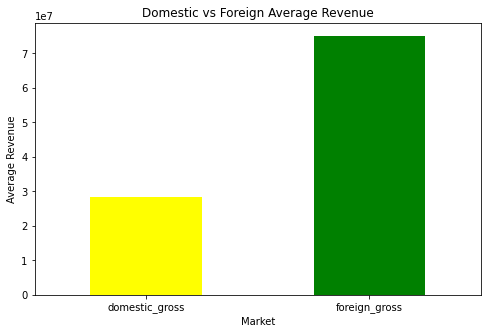

In [84]:
# Plotting comparison of domestic and foreign revenue

market_avg.plot(kind='bar', figsize=(8,5), color=['Yellow', 'Green'])

plt.title("Domestic vs Foreign Average Revenue")
plt.ylabel("Average Revenue")
plt.xlabel("Market")
plt.xticks(rotation=0)

plt.show()

In [55]:
# Budget vs revenue (if merged with tn dataset)
# Budget strategically
# High budget ≠ guaranteed success
# ROI matters more than revenue
merged_1['profit'] = merged_1['worldwide_gross'] - merged_1['production_budget']
# ROI
merged_1['roi'] = merged_1['profit'] / merged_1['production_budget']

In [56]:
# Learn from top studios
# Genre choices, Release timing and Franchise strategy

# “To maximize box office success, the studio should prioritize high-budget action and adventure films with global appeal. These genres consistently generate the highest revenues, especially in international markets. Additionally, investing in franchise-based content and focusing on return on investment rather than just total revenue will improve long-term profitability.”